# Model comparison benchmark

Four comparisons (pulse L1 and trace L1) with **early-stopped** Multires training (max 100 epochs) and **early-stopped** PCGPA (max 200 iter, patience 50).

| # | Models |
|---|--------|
| 1 | Multires 60K, PCGPA, Multires 6K, Multires(6K)→PCGPA |
| 2 | Multires 60K, PCGPA, Multires 2K, Multires(2K)→PCGPA |
| 3 | Same as 1 — **trace L1** vs noisy trace |
| 4 | Same as 2 — **trace L1** vs noisy trace |


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from dataset_utils import PulseGridConfig, build_frog_dataloaders
from frognet import FROGNet
from model_comparison_benchmark import (
    load_benchmark_sweep,
    load_or_train_benchmark_models,
    plot_benchmark_comparison,
    run_hybrid_benchmark_sweep,
    run_multires_benchmark_sweep,
    run_pcgpa_benchmark_sweep,
    save_benchmark_sweep,
)
from trace_noise import add_trace_noise_awgn as add_trace_noise

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0
N = 64
T_TOTAL = 250.0
DT = T_TOTAL / N
SIGMA_OMEGA = 0.05 * (2 * np.pi / DT)
N_VAL = 512
N_TEST = 512
BATCH_SIZE = 64
LR = 1e-3
TRAIN_SNR_DB_RANGE = (0.0, 30.0)
VAL_SNR_DB = 15.0
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)

MAX_EPOCHS = 100
TRAIN_PATIENCE = 15
PCGPA_MAXITER = 200
PCGPA_EARLY_STOP = 50
PCGPA_N_TEST = 32
PCGPA_N_RESTARTS = 3

BENCH_DIR = Path("checkpoints/benchmark")
BENCH_DIR.mkdir(parents=True, exist_ok=True)
FORCE_RETRAIN = False
FORCE_RECOMPUTE_SWEEPS = False

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
_bundle = build_frog_dataloaders(
    n_train=2048,
    n_val=N_VAL,
    n_test=N_TEST,
    batch_size=BATCH_SIZE,
    seed=SEED,
    device=DEVICE,
    grid=PulseGridConfig(n=N, sigma_omega=SIGMA_OMEGA),
)
test_loader = _bundle.test_loader
I_test = test_loader.dataset.tensors[0]
E_test = test_loader.dataset.tensors[1]
_frog = FROGNet(num_delay_steps=N).to(DEVICE)
_frog.eval()
print("test pulses:", I_test.shape[0])


test pulses: 512


## Train Multires 6K & 2K (early stopping); load Multires 60K from pretrained checkpoint


In [3]:
# Multires 60K: load only (checkpoints/large_60k_multires_50ep.pt) — never retrained here.
# Multires 6K & 2K: early-stop train (max 100 epochs) if checkpoint missing or FORCE_RETRAIN.
_FORCE_RETRAIN_SET = frozenset({"multires_6k", "multires_2k"}) if FORCE_RETRAIN else frozenset()

trained = load_or_train_benchmark_models(
    bench_dir=BENCH_DIR,
    device=DEVICE,
    seed=SEED,
    n_val=N_VAL,
    n_test=N_TEST,
    batch_size=BATCH_SIZE,
    lr=LR,
    max_epochs=MAX_EPOCHS,
    patience=TRAIN_PATIENCE,
    train_snr_db_range=TRAIN_SNR_DB_RANGE,
    val_snr_db=VAL_SNR_DB,
    n=N,
    add_noise_fn=add_trace_noise,
    force_retrain=_FORCE_RETRAIN_SET,
)

Loaded multires_60k (pretrained, no retrain): checkpoints\large_60k_multires_50ep.pt
Loaded multires_6k: checkpoints\benchmark\multires_6k_es.pt (best epoch 19)
Loaded multires_2k: checkpoints\benchmark\multires_2k_es.pt (best epoch 35)


## SNR sweeps (cached)


In [4]:
def _load_or_run(path, runner, label):
    if path.is_file() and not FORCE_RECOMPUTE_SWEEPS:
        sw = load_benchmark_sweep(path)
        if sw.similarity_error is not None:
            print(f"Loaded {label}: {path}")
            return sw
        print(f"Stale cache (no SIMILARITY_ERROR) — recomputing {label} …")
    sw = runner()
    save_benchmark_sweep(path, sw)
    print(f"Saved {label}: {path}")
    return sw

_i_np = I_test.cpu().numpy()
_e_np = E_test.cpu().numpy()

sweep_60k = _load_or_run(
    BENCH_DIR / "sweep_multires_60k_es.npz",
    lambda: run_multires_benchmark_sweep(
        trained["multires_60k"], test_loader, SNR_SWEEP_DB,
        label="Multires 60K (best amb.)", frog=_frog, device=DEVICE, add_noise_fn=add_trace_noise,
    ),
    "Multires 60K",
)
sweep_6k = _load_or_run(
    BENCH_DIR / "sweep_multires_6k_es.npz",
    lambda: run_multires_benchmark_sweep(
        trained["multires_6k"], test_loader, SNR_SWEEP_DB,
        label="Multires 6K (best amb.)", frog=_frog, device=DEVICE, add_noise_fn=add_trace_noise,
    ),
    "Multires 6K",
)
sweep_2k = _load_or_run(
    BENCH_DIR / "sweep_multires_2k_es.npz",
    lambda: run_multires_benchmark_sweep(
        trained["multires_2k"], test_loader, SNR_SWEEP_DB,
        label="Multires 2K (best amb.)", frog=_frog, device=DEVICE, add_noise_fn=add_trace_noise,
    ),
    "Multires 2K",
)
sweep_pcgpa = _load_or_run(
    BENCH_DIR / "sweep_pcgpa_es.npz",
    lambda: run_pcgpa_benchmark_sweep(
        _i_np, _e_np, SNR_SWEEP_DB,
        label="PCGPA (best amb.)",
        add_noise_fn=add_trace_noise, dt=DT, frog=_frog, device=DEVICE,
        pcgpa_maxiter=PCGPA_MAXITER, pcgpa_early_stop_patience=PCGPA_EARLY_STOP,
        n_subsample=PCGPA_N_TEST, seed=SEED, n_restarts=PCGPA_N_RESTARTS,
        sigma_omega=SIGMA_OMEGA,
    ),
    "PCGPA",
)
sweep_hybrid_6k = _load_or_run(
    BENCH_DIR / "sweep_hybrid_6k_es.npz",
    lambda: run_hybrid_benchmark_sweep(
        trained["multires_6k"], _i_np, _e_np, SNR_SWEEP_DB,
        label="Multires(6K)→PCGPA (best amb. init)",
        add_noise_fn=add_trace_noise, dt=DT, frog=_frog, device=DEVICE,
        pcgpa_maxiter=PCGPA_MAXITER, pcgpa_early_stop_patience=PCGPA_EARLY_STOP,
        n_subsample=PCGPA_N_TEST, seed=SEED,
    ),
    "Hybrid 6K",
)
sweep_hybrid_2k = _load_or_run(
    BENCH_DIR / "sweep_hybrid_2k_es.npz",
    lambda: run_hybrid_benchmark_sweep(
        trained["multires_2k"], _i_np, _e_np, SNR_SWEEP_DB,
        label="Multires(2K)→PCGPA (best amb. init)",
        add_noise_fn=add_trace_noise, dt=DT, frog=_frog, device=DEVICE,
        pcgpa_maxiter=PCGPA_MAXITER, pcgpa_early_stop_patience=PCGPA_EARLY_STOP,
        n_subsample=PCGPA_N_TEST, seed=SEED,
    ),
    "Hybrid 2K",
)

Loaded Multires 60K: checkpoints\benchmark\sweep_multires_60k_es.npz
Loaded Multires 6K: checkpoints\benchmark\sweep_multires_6k_es.npz
Stale cache (no SIMILARITY_ERROR) — recomputing Multires 2K …
Multires 2K (best amb.) @ -10.0 dB …
Multires 2K (best amb.) @ -5.0 dB …
Multires 2K (best amb.) @ 0.0 dB …
Multires 2K (best amb.) @ 5.0 dB …
Multires 2K (best amb.) @ 10.0 dB …
Multires 2K (best amb.) @ 15.0 dB …
Multires 2K (best amb.) @ 20.0 dB …
Multires 2K (best amb.) @ 25.0 dB …
Multires 2K (best amb.) @ 30.0 dB …


d:\Haim\Haim 3rd paper\Ultra-Fast project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved Multires 2K: checkpoints\benchmark\sweep_multires_2k_es.npz
Loaded PCGPA: checkpoints\benchmark\sweep_pcgpa_es.npz
Stale cache (no SIMILARITY_ERROR) — recomputing Hybrid 6K …
Multires(6K)→PCGPA (best amb. init) @ -10.0 dB …


Multires(6K)→PCGPA (best amb. init) @ -5.0 dB …


Multires(6K)→PCGPA (best amb. init) @ 0.0 dB …


...

Multires(2K)→PCGPA (best amb. init) @ 15.0 dB …


Multires(2K)→PCGPA (best amb. init) @ 20.0 dB …


Multires(2K)→PCGPA (best amb. init) @ 25.0 dB …


Multires(2K)→PCGPA (best amb. init) @ 30.0 dB …


Saved Hybrid 2K: checkpoints\benchmark\sweep_hybrid_2k_es.npz


## Comparison 1 — pulse L1 (60K, PCGPA, 6K, 6K→PCGPA)


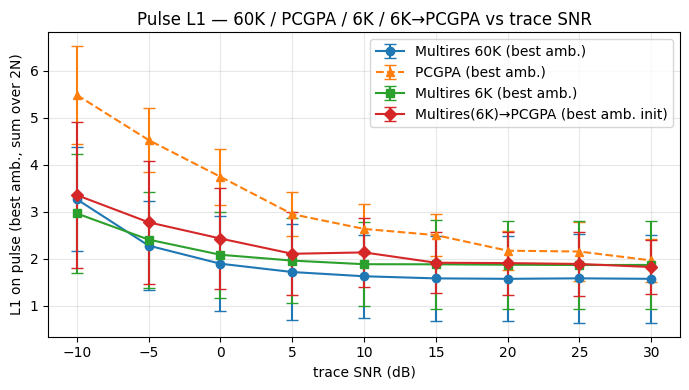

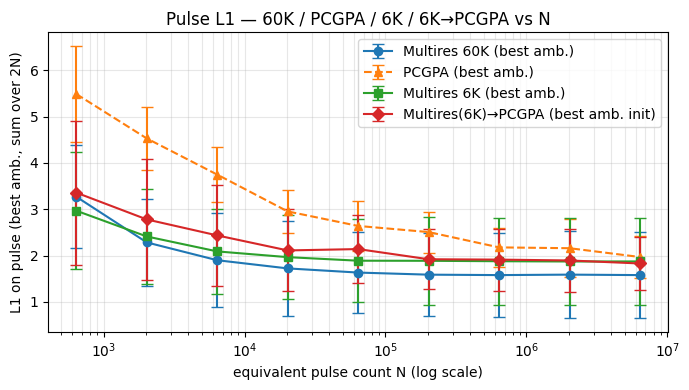

In [5]:
plot_benchmark_comparison(
    SNR_SWEEP_DB,
    [sweep_60k, sweep_pcgpa, sweep_6k, sweep_hybrid_6k],
    metric="pulse_l1",
    title_prefix="Pulse L1 — 60K / PCGPA / 6K / 6K→PCGPA",
)

## Comparison 2 — pulse L1 (60K, PCGPA, 2K, 2K→PCGPA)


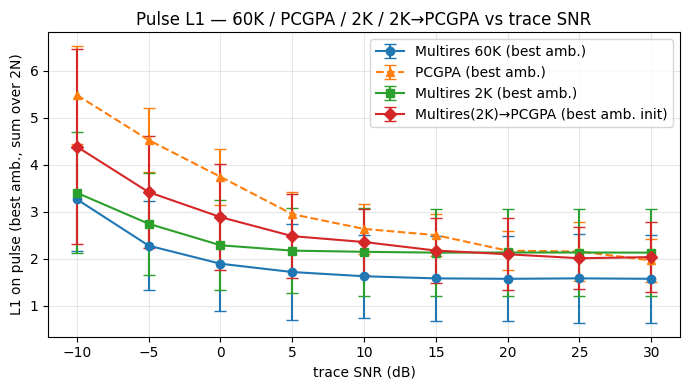

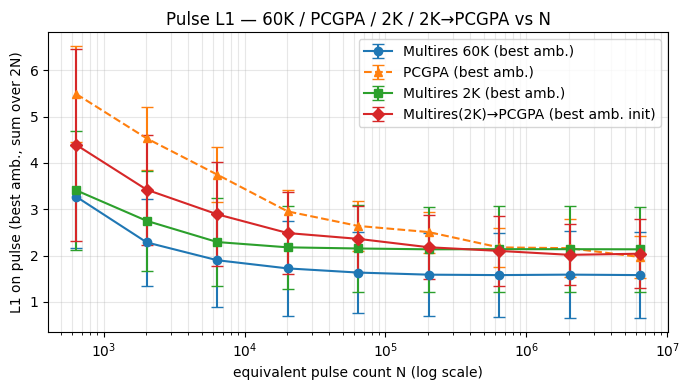

In [6]:
plot_benchmark_comparison(
    SNR_SWEEP_DB,
    [sweep_60k, sweep_pcgpa, sweep_2k, sweep_hybrid_2k],
    metric="pulse_l1",
    title_prefix="Pulse L1 — 60K / PCGPA / 2K / 2K→PCGPA",
)

## Comparison 3 — trace L1 (60K, PCGPA, 6K, 6K→PCGPA)


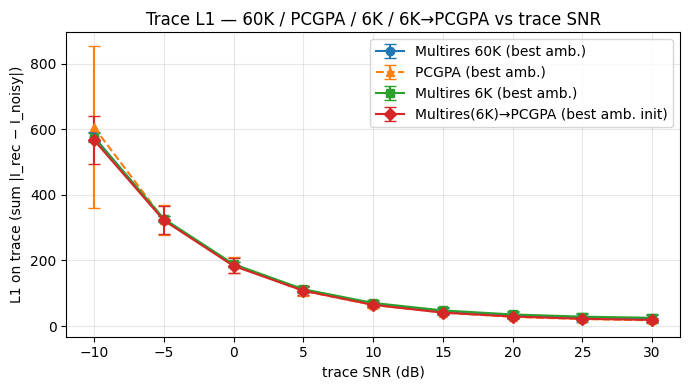

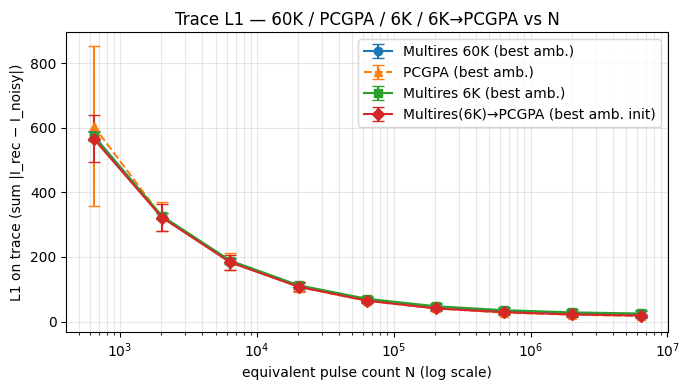

In [7]:
plot_benchmark_comparison(
    SNR_SWEEP_DB,
    [sweep_60k, sweep_pcgpa, sweep_6k, sweep_hybrid_6k],
    metric="trace_l1",
    title_prefix="Trace L1 — 60K / PCGPA / 6K / 6K→PCGPA",
)

## Comparison 4 — trace L1 (60K, PCGPA, 2K, 2K→PCGPA)


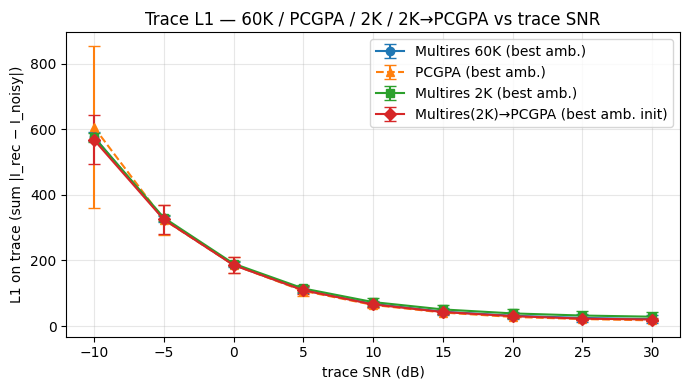

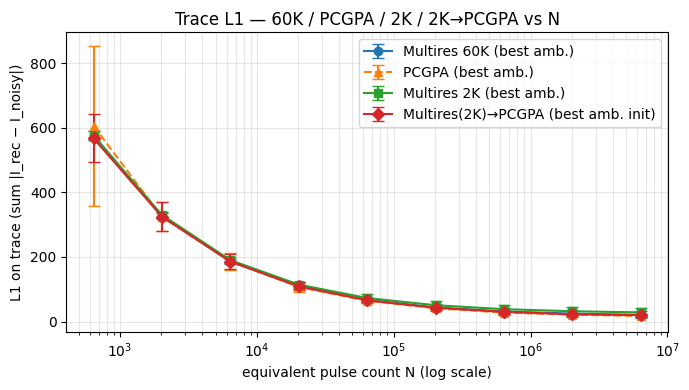

In [8]:
plot_benchmark_comparison(
    SNR_SWEEP_DB,
    [sweep_60k, sweep_pcgpa, sweep_2k, sweep_hybrid_2k],
    metric="trace_l1",
    title_prefix="Trace L1 — 60K / PCGPA / 2K / 2K→PCGPA",
)

## U-Net trace → pulse (6K, early stopping)

**Model:** `TraceToPulseUNet` — 3-level encoder (64→32→16→8), matching decoder with skip connections, then global-average pool + FC head → packed Re/Im pulse `[2N]`.

**I/O:** input noisy trace `[B, 1, 64, 64]`; output `[B, 128]` (same convention as Multires).

**Training (this notebook):**
- **6,000** synthetic train pulses (sweet spot: enough diversity without 60K training cost).
- AWGN on traces: uniform SNR **0–30 dB** per batch; validation @ **15 dB**.
- Loss: **packed pulse L1** (supervised, same as Multires benchmark).
- Adam `lr=1e-3`, max **100** epochs, early stop **patience 15**; best weights restored.
- Checkpoint: `checkpoints/benchmark/unet_6k_es.pt`.

**Demo below:** random test pulse, trace @ **30 dB** SNR — |E(t)|, phase, and clean/noisy traces (same style as `reconstruction_snr_experiments.ipynb`).

In [9]:
from pathlib import Path

from model_comparison_benchmark import train_unet_early_stop
from train import load_checkpoint

UNET_N_TRAIN = 6_000
UNET_CKPT = BENCH_DIR / "unet_6k_es.pt"
FORCE_RETRAIN_UNET = False

if UNET_CKPT.is_file() and not FORCE_RETRAIN_UNET:
    unet_model, unet_ckpt = load_checkpoint(UNET_CKPT, DEVICE)
    print(f"Loaded U-Net: {UNET_CKPT}")
    print(
        f"  best epoch {unet_ckpt.get('best_epoch', '?')}, "
        f"val L1 {unet_ckpt.get('best_val_l1', float('nan')):.5f}"
    )
else:
    unet_model, unet_result = train_unet_early_stop(
        n_train=UNET_N_TRAIN,
        checkpoint_path=UNET_CKPT,
        experiment_name="unet_6k_es",
        device=DEVICE,
        seed=SEED,
        n_val=N_VAL,
        n_test=N_TEST,
        batch_size=BATCH_SIZE,
        lr=LR,
        max_epochs=MAX_EPOCHS,
        patience=TRAIN_PATIENCE,
        train_snr_db_range=TRAIN_SNR_DB_RANGE,
        val_snr_db=VAL_SNR_DB,
        n=N,
        verbose=True,
    )
    print(
        f"Trained U-Net: best epoch {unet_result.best_epoch}, "
        f"val L1 {unet_result.best_val_l1:.5f}"
    )

unet_model.eval()

Loaded U-Net: checkpoints\benchmark\unet_6k_es.pt
  best epoch 77, val L1 3.23865


TraceToPulseUNet(
  (enc1): _UNetConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): _UNetDown(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): _UNetConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
  )
  (enc3): _UNetDown(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): _UNetConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, 

U-Net @ 30 dB — random test pulse index 435
  best L1 ambiguity = 1.18199


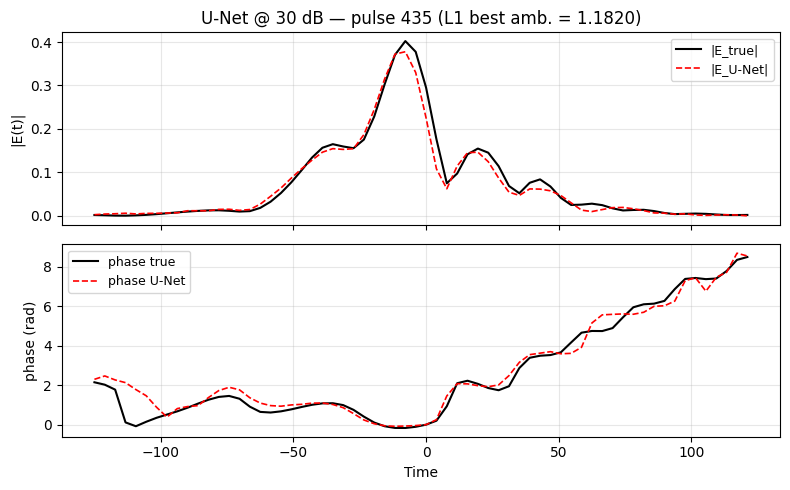

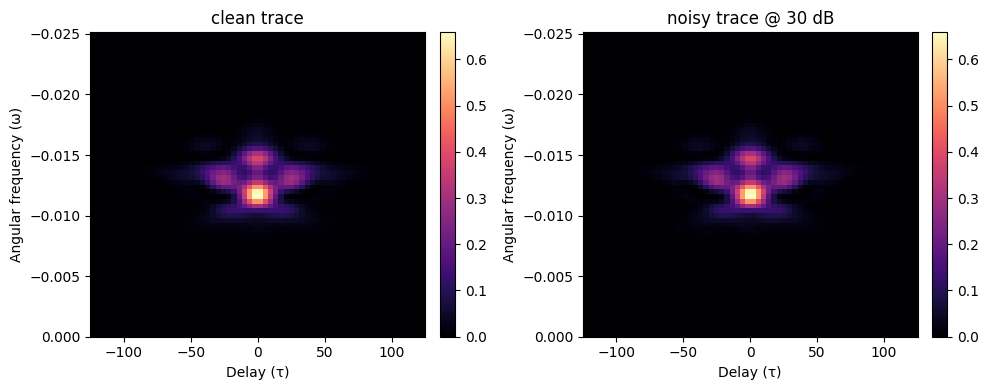

In [10]:
from pulse_metrics import (
    best_l1_ambiguity_field,
    l1_packed_mae,
    packed_batch_to_complex,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)

_PLOT_SNR_DB = 30.0
_rng = np.random.default_rng(SEED)
_plot_i = int(_rng.integers(0, I_test.shape[0]))
t_axis = _bundle.t_vec
w_vec = _bundle.w_vec

with torch.no_grad():
    I_clean_1 = I_test[_plot_i : _plot_i + 1].to(DEVICE)
    I_n = add_trace_noise(I_clean_1, _PLOT_SNR_DB)
    E_pred = unet_model(I_n.unsqueeze(1))

_i_noisy_np = I_n.squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())
e_rec = packed_batch_to_complex(E_pred)[0]
e_rec_amb = best_l1_ambiguity_field(e_rec, e_true)
_e_true_packed = E_test[_plot_i].cpu().numpy()
_l1_best = l1_packed_mae(e_rec_amb, _e_true_packed, use_best_ambiguity=False)

print(f"U-Net @ {_PLOT_SNR_DB:.0f} dB — random test pulse index {_plot_i}")
print(f"  best L1 ambiguity = {_l1_best:.5f}")

_ph_true, _ = unwrap_phases_for_overlay(e_rec_amb, e_true)
_, ph_rec = unwrap_phases_for_overlay(e_rec_amb, e_true)

fig_e, axes_e = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes_e[0].plot(t_axis, np.abs(e_true), "k-", lw=1.5, label="|E_true|")
axes_e[0].plot(t_axis, np.abs(e_rec_amb), "r--", lw=1.2, label="|E_U-Net|")
axes_e[0].set_ylabel("|E(t)|")
axes_e[0].set_title(f"U-Net @ {_PLOT_SNR_DB:.0f} dB — pulse {_plot_i} (L1 best amb. = {_l1_best:.4f})")
axes_e[0].legend(fontsize=9)
axes_e[0].grid(alpha=0.3)

axes_e[1].plot(t_axis, _ph_true, "k-", lw=1.5, label="phase true")
axes_e[1].plot(t_axis, ph_rec, "r--", lw=1.2, label="phase U-Net")
axes_e[1].set_xlabel("Time")
axes_e[1].set_ylabel("phase (rad)")
axes_e[1].legend(fontsize=9)
axes_e[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

_i_clean_np = I_clean_1.squeeze(0).cpu().numpy()
_trace_clean, _tau_axis, _omega_plot = prepare_frog_trace_for_plot(
    _i_clean_np, omega_axis=w_vec, dt=DT
)
_trace_noisy, _, _ = prepare_frog_trace_for_plot(_i_noisy_np, omega_axis=w_vec, dt=DT)
_extent = [_tau_axis[0], _tau_axis[-1], _omega_plot[0], _omega_plot[-1]]
_vmax = max(_trace_clean.max(), _trace_noisy.max())

fig_tr, axes_tr = plt.subplots(1, 2, figsize=(10, 4))
for ax, img, title in (
    (axes_tr[0], _trace_clean, "clean trace"),
    (axes_tr[1], _trace_noisy, f"noisy trace @ {_PLOT_SNR_DB:.0f} dB"),
):
    im = ax.imshow(
        img,
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=_extent,
        vmin=0.0,
        vmax=_vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("Delay (τ)")
    ax.set_ylabel("Angular frequency (ω)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Four-model comparison — PCGPA, Multires 6K/60K, U-Net

Pulse **L1**, **SIMILARITY_ERROR** (best ambiguity), and **trace L1** vs trace SNR.
U-Net sweep uses the same test loader as Multires (512 pulses); PCGPA uses `PCGPA_N_TEST` subsample.

Loaded U-Net 6K: checkpoints\benchmark\sweep_unet_6k_es.npz


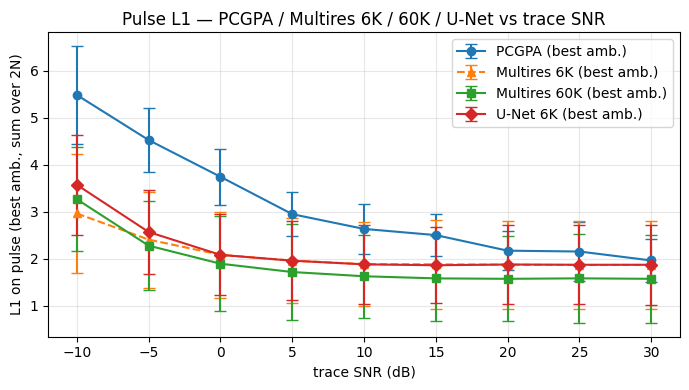

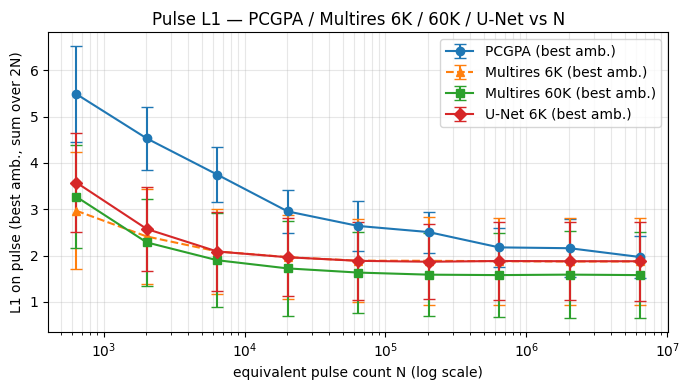

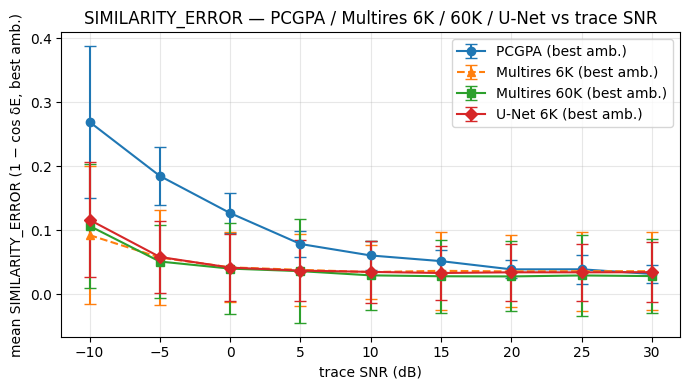

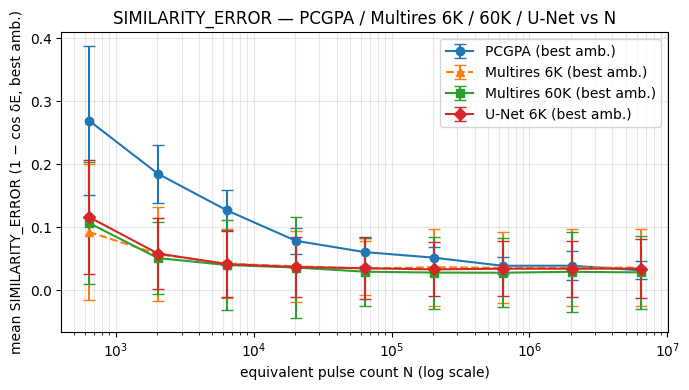

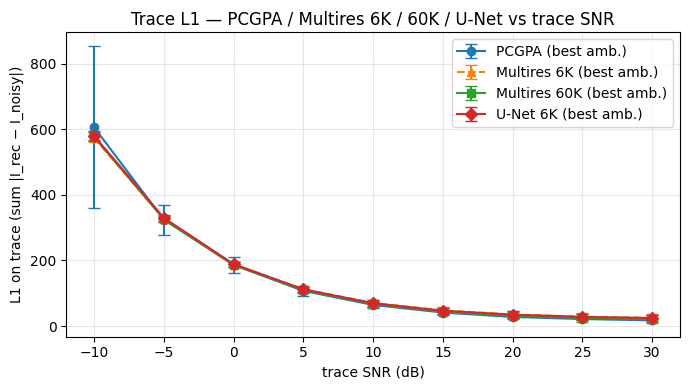

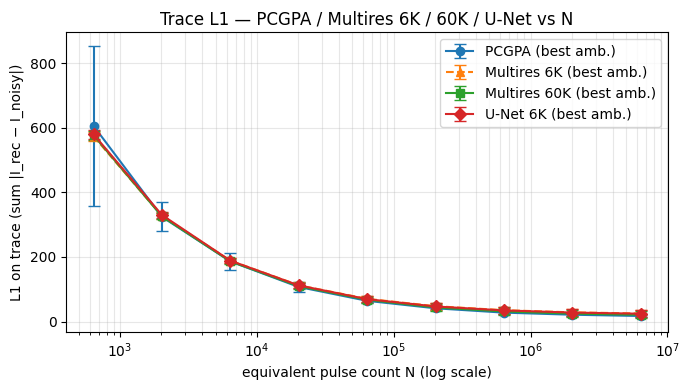

In [11]:
if "unet_model" not in globals():
    from train import load_checkpoint

    unet_model, _ = load_checkpoint(UNET_CKPT, DEVICE)
    unet_model.eval()

sweep_unet = _load_or_run(
    BENCH_DIR / "sweep_unet_6k_es.npz",
    lambda: run_multires_benchmark_sweep(
        unet_model,
        test_loader,
        SNR_SWEEP_DB,
        label="U-Net 6K (best amb.)",
        frog=_frog,
        device=DEVICE,
        add_noise_fn=add_trace_noise,
    ),
    "U-Net 6K",
)

_four_model_sweeps = [sweep_pcgpa, sweep_6k, sweep_60k, sweep_unet]
_four_model_fmts = ["-o", "--^", "-s", "-D"]

for _metric, _title in (
    ("pulse_l1", "Pulse L1 — PCGPA / Multires 6K / 60K / U-Net"),
    ("similarity_error", "SIMILARITY_ERROR — PCGPA / Multires 6K / 60K / U-Net"),
    ("trace_l1", "Trace L1 — PCGPA / Multires 6K / 60K / U-Net"),
):
    plot_benchmark_comparison(
        SNR_SWEEP_DB,
        _four_model_sweeps,
        metric=_metric,
        title_prefix=_title,
        fmts=_four_model_fmts,
    )

## Multires 6K — uniform SNR vs. SNR curriculum

**Standard** (`multires_6k_es.pt`): random train SNR uniform in **0–30 dB** for all epochs (same as Comparison 1).

**Curriculum** (`multires_6k_curriculum_es.pt`): 3 phases over max 100 epochs (early stopping, patience 15):
| Phase | Epochs (approx.) | Train SNR range |
|-------|------------------|-----------------|
| 1 | 1–33 | 20–30 dB |
| 2 | 34–66 | 10–25 dB |
| 3 | 67–100 | 0–30 dB |

Train: 6K pulses, val @ 15 dB. Test metrics: pulse **L1** and **SIMILARITY_ERROR** (best ambiguity) vs trace SNR.

Run training once: `python scripts/run_multires_6k_curriculum.py`

In [ ]:
from pathlib import Path

from model_comparison_benchmark import load_benchmark_sweep, plot_benchmark_comparison
from train import load_checkpoint

CURR_CKPT = BENCH_DIR / "multires_6k_curriculum_es.pt"
CURR_SWEEP_PATH = BENCH_DIR / "sweep_multires_6k_curriculum_es.npz"
STD_SWEEP_PATH = BENCH_DIR / "sweep_multires_6k_es.npz"

if not CURR_CKPT.is_file():
    raise FileNotFoundError(
        f"Missing {CURR_CKPT}. Run: python scripts/run_multires_6k_curriculum.py"
    )

curr_model, curr_meta = load_checkpoint(CURR_CKPT, DEVICE)
print(
    f"Curriculum model: best epoch {curr_meta.get('best_epoch', '?')}, "
    f"stopped @ {curr_meta.get('stopped_epoch', '?')}, "
    f"snr_curriculum={curr_meta.get('snr_curriculum', False)}"
)

if not CURR_SWEEP_PATH.is_file() or FORCE_RECOMPUTE_SWEEPS:
    from frognet import FROGNet

    _frog_curr = FROGNet(num_delay_steps=N).to(DEVICE)
    sweep_6k_curriculum = run_multires_benchmark_sweep(
        curr_model,
        test_loader,
        SNR_SWEEP_DB,
        label="Multires 6K curriculum",
        frog=_frog_curr,
        device=DEVICE,
        add_noise_fn=add_trace_noise,
    )
    save_benchmark_sweep(CURR_SWEEP_PATH, sweep_6k_curriculum)
    print(f"Saved {CURR_SWEEP_PATH}")
else:
    sweep_6k_curriculum = load_benchmark_sweep(CURR_SWEEP_PATH)
    print(f"Loaded {CURR_SWEEP_PATH}")

if not STD_SWEEP_PATH.is_file():
    raise FileNotFoundError(f"Missing standard sweep {STD_SWEEP_PATH}. Run cell 6 first.")

sweep_6k_standard = load_benchmark_sweep(STD_SWEEP_PATH)
sweep_6k_standard.pulse_l1.label = "Multires 6K (uniform SNR)"
sweep_6k_curriculum.pulse_l1.label = "Multires 6K (curriculum)"

_compare_pair = [sweep_6k_standard, sweep_6k_curriculum]

plot_benchmark_comparison(
    SNR_SWEEP_DB,
    _compare_pair,
    metric="pulse_l1",
    title_prefix="Multires 6K — pulse L1",
    fmts=["-o", "--s"],
)
plt.show()

plot_benchmark_comparison(
    SNR_SWEEP_DB,
    _compare_pair,
    metric="similarity_error",
    title_prefix="Multires 6K — SIMILARITY_ERROR",
    fmts=["-o", "--s"],
)
plt.show()

print(f"{'SNR (dB)':>8} | {'L1 uniform':>10} | {'L1 curr.':>10} | {'Sim unif.':>10} | {'Sim curr.':>10}")
print("-" * 56)
for i, snr_db in enumerate(SNR_SWEEP_DB):
    print(
        f"{float(snr_db):8.0f} | "
        f"{sweep_6k_standard.pulse_l1.mean[i]:10.4f} | "
        f"{sweep_6k_curriculum.pulse_l1.mean[i]:10.4f} | "
        f"{sweep_6k_standard.similarity_error.mean[i]:10.5f} | "
        f"{sweep_6k_curriculum.similarity_error.mean[i]:10.5f}"
    )

## Multires / U-Net 6K with auxiliary SNR head

Dual-output models (`multires_snr`, `unet_snr`): packed pulse `[2N]` **+** scalar trace SNR (dB).

**Training loss:** `L1(pulse) + 0.05 · L1(SNR_pred, SNR_true)` — same 6K data, early stopping, val @ 15 dB (pulse L1 only).

Checkpoints: `multires_6k_snr_es.pt`, `unet_6k_snr_es.pt`. Train: `python scripts/run_snr_head_models.py`

Compare each new model to its baseline (without SNR head) on test pulse **L1** and **SIMILARITY_ERROR**.


=== Multires 6K vs Multires 6K + SNR head ===


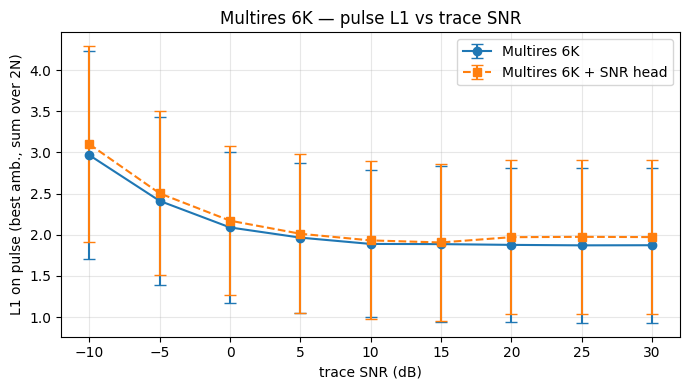

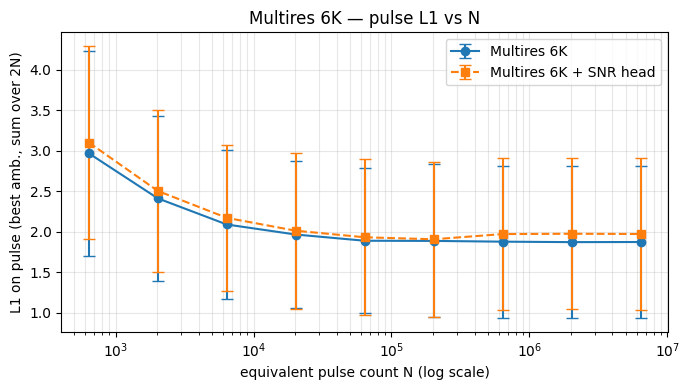

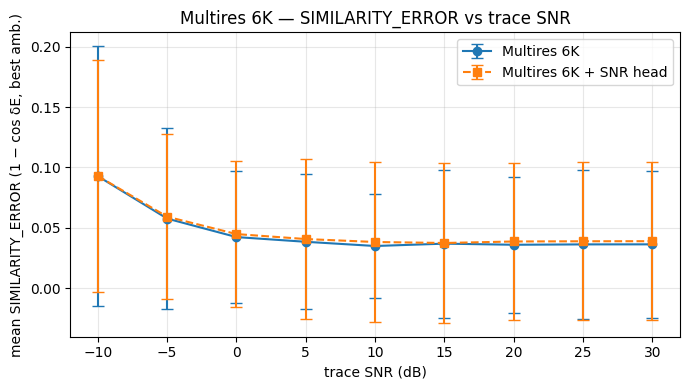

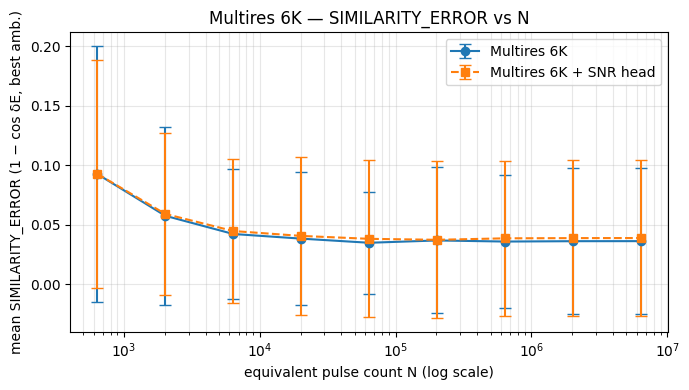

   SNR |   L1 base |    L1+SNR |   Sim base |    Sim+SNR
   -10 |    2.9663 |    3.0994 |    0.09272 |    0.09286
    -5 |    2.4106 |    2.5022 |    0.05762 |    0.05918
     0 |    2.0883 |    2.1705 |    0.04231 |    0.04480
     5 |    1.9646 |    2.0115 |    0.03841 |    0.04068
    10 |    1.8878 |    1.9307 |    0.03493 |    0.03824
    15 |    1.8858 |    1.9059 |    0.03687 |    0.03742
    20 |    1.8765 |    1.9701 |    0.03596 |    0.03867
    25 |    1.8708 |    1.9741 |    0.03626 |    0.03885
    30 |    1.8723 |    1.9710 |    0.03630 |    0.03892

=== U-Net 6K vs U-Net 6K + SNR head ===


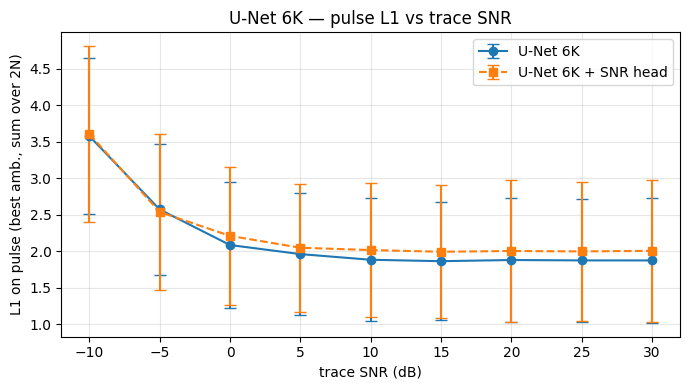

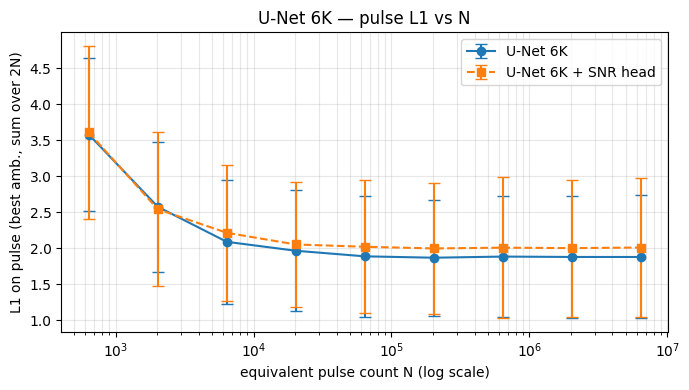

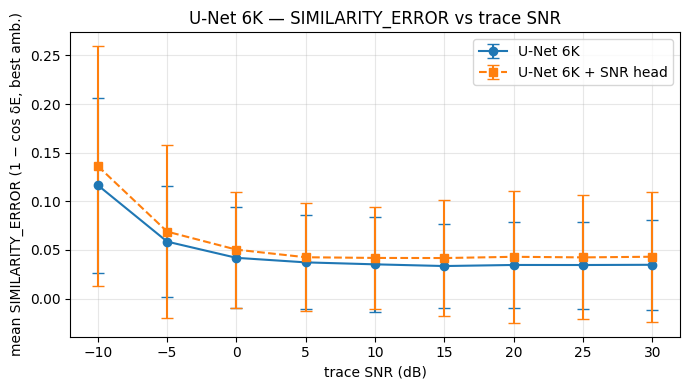

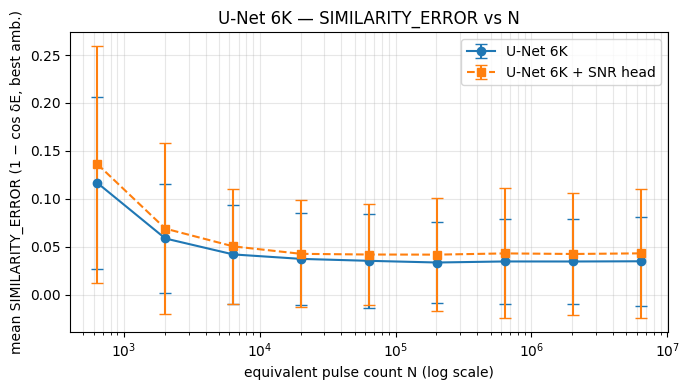

   SNR |   L1 base |    L1+SNR |   Sim base |    Sim+SNR
   -10 |    3.5753 |    3.6046 |    0.11651 |    0.13616
    -5 |    2.5724 |    2.5381 |    0.05855 |    0.06884
     0 |    2.0863 |    2.2116 |    0.04190 |    0.05031
     5 |    1.9624 |    2.0494 |    0.03723 |    0.04250
    10 |    1.8849 |    2.0178 |    0.03521 |    0.04180
    15 |    1.8655 |    1.9944 |    0.03347 |    0.04168
    20 |    1.8814 |    2.0048 |    0.03457 |    0.04296
    25 |    1.8761 |    1.9991 |    0.03452 |    0.04237
    30 |    1.8757 |    2.0069 |    0.03475 |    0.04302


In [13]:
from model_comparison_benchmark import load_benchmark_sweep, plot_benchmark_comparison

_SNR_PAIRS = (
    (
        BENCH_DIR / "sweep_multires_6k_es.npz",
        BENCH_DIR / "sweep_multires_6k_snr_es.npz",
        "Multires 6K",
        "Multires 6K + SNR head",
    ),
    (
        BENCH_DIR / "sweep_unet_6k_es.npz",
        BENCH_DIR / "sweep_unet_6k_snr_es.npz",
        "U-Net 6K",
        "U-Net 6K + SNR head",
    ),
)

for base_path, snr_path, base_label, snr_label in _SNR_PAIRS:
    if not snr_path.is_file():
        raise FileNotFoundError(f"Missing {snr_path}. Run: python scripts/run_snr_head_models.py")
    sweep_base = load_benchmark_sweep(base_path)
    sweep_snr = load_benchmark_sweep(snr_path)
    sweep_base.pulse_l1.label = base_label
    sweep_snr.pulse_l1.label = snr_label
    if sweep_snr.similarity_error is not None:
        sweep_snr.similarity_error.label = snr_label
    if sweep_base.similarity_error is not None:
        sweep_base.similarity_error.label = base_label

    print(f"\n=== {base_label} vs {snr_label} ===")
    plot_benchmark_comparison(
        SNR_SWEEP_DB,
        [sweep_base, sweep_snr],
        metric="pulse_l1",
        title_prefix=f"{base_label} — pulse L1",
        fmts=["-o", "--s"],
    )
    plt.show()
    plot_benchmark_comparison(
        SNR_SWEEP_DB,
        [sweep_base, sweep_snr],
        metric="similarity_error",
        title_prefix=f"{base_label} — SIMILARITY_ERROR",
        fmts=["-o", "--s"],
    )
    plt.show()

    print(f"{'SNR':>6} | {'L1 base':>9} | {'L1+SNR':>9} | {'Sim base':>10} | {'Sim+SNR':>10}")
    for i, snr_db in enumerate(SNR_SWEEP_DB):
        print(
            f"{float(snr_db):6.0f} | "
            f"{sweep_base.pulse_l1.mean[i]:9.4f} | "
            f"{sweep_snr.pulse_l1.mean[i]:9.4f} | "
            f"{sweep_base.similarity_error.mean[i]:10.5f} | "
            f"{sweep_snr.similarity_error.mean[i]:10.5f}"
        )

## U-Net 8K vs Multires 6K (regular models)

Train **regular** `TraceToPulseUNet` on **8K** pulses (same protocol as U-Net 6K: early stop, SNR 0–30 dB, val @ 15 dB).

Checkpoint: `checkpoints/benchmark/unet_8k_es.pt`. Train: `python scripts/run_unet_8k_vs_multires.py`

Compare pulse **L1** and **SIMILARITY_ERROR** vs **Multires 6K** (`sweep_multires_6k_es.npz`).

Loaded U-Net 8K: checkpoints\benchmark\unet_8k_es.pt (best epoch 71)
Loaded U-Net 8K: checkpoints\benchmark\sweep_unet_8k_es.npz


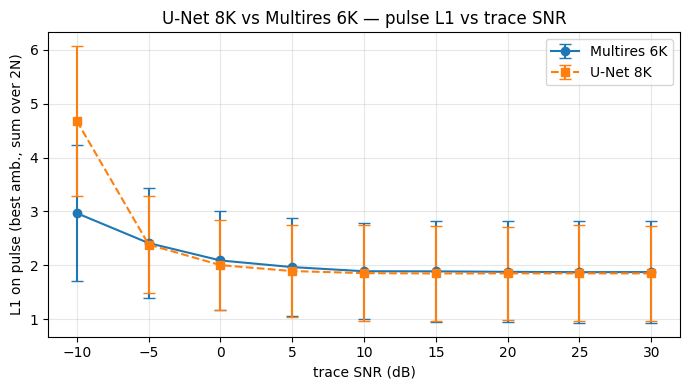

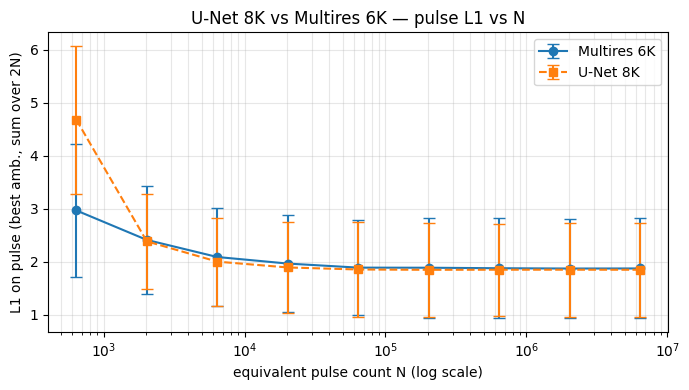

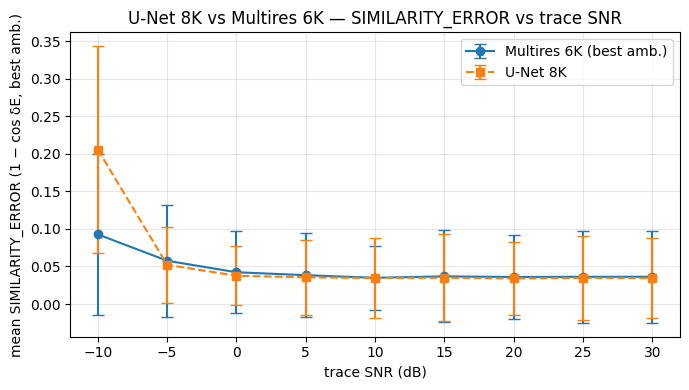

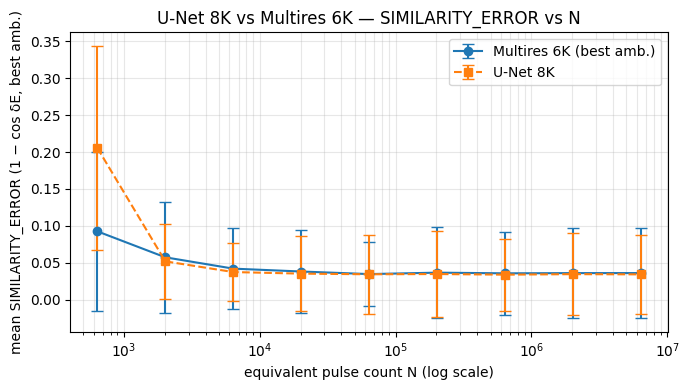

SNR (dB) |  L1 Multires |  L1 U-Net 8K |  Sim Multires |  Sim U-Net 8K
     -10 |       2.9663 |       4.6772 |       0.09272 |       0.20547
      -5 |       2.4106 |       2.3835 |       0.05762 |       0.05217
       0 |       2.0883 |       2.0010 |       0.04231 |       0.03768
       5 |       1.9646 |       1.8910 |       0.03841 |       0.03555
      10 |       1.8878 |       1.8526 |       0.03493 |       0.03467
      15 |       1.8858 |       1.8466 |       0.03687 |       0.03500
      20 |       1.8765 |       1.8483 |       0.03596 |       0.03416
      25 |       1.8708 |       1.8486 |       0.03626 |       0.03485
      30 |       1.8723 |       1.8477 |       0.03630 |       0.03455


In [15]:
from model_comparison_benchmark import (
    load_benchmark_sweep,
    plot_benchmark_comparison,
    run_multires_benchmark_sweep,
    save_benchmark_sweep,
    train_unet_early_stop,
)
from train import load_checkpoint

UNET_8K_CKPT = BENCH_DIR / "unet_8k_es.pt"
UNET_8K_SWEEP = BENCH_DIR / "sweep_unet_8k_es.npz"
FORCE_RETRAIN_UNET_8K = False

if UNET_8K_CKPT.is_file() and not FORCE_RETRAIN_UNET_8K:
    unet_8k_model, _unet_8k_meta = load_checkpoint(UNET_8K_CKPT, DEVICE)
    print(f"Loaded U-Net 8K: {UNET_8K_CKPT} (best epoch {_unet_8k_meta.get('best_epoch', '?')})")
else:
    unet_8k_model, _unet_8k_res = train_unet_early_stop(
        n_train=8_000,
        checkpoint_path=UNET_8K_CKPT,
        experiment_name="unet_8k_es",
        device=DEVICE,
        seed=SEED,
        n_val=N_VAL,
        n_test=N_TEST,
        batch_size=BATCH_SIZE,
        lr=LR,
        max_epochs=MAX_EPOCHS,
        patience=TRAIN_PATIENCE,
        val_snr_db=VAL_SNR_DB,
        n=N,
        add_noise_fn=add_trace_noise,
    )
    print(
        f"Trained U-Net 8K: best epoch {_unet_8k_res.best_epoch}, "
        f"val L1 {_unet_8k_res.best_val_l1:.5f}"
    )
unet_8k_model.eval()


def _sweep_unet_8k_cpu(model):
    from frognet import FROGNet

    _cpu = torch.device("cpu")
    _bundle = build_frog_dataloaders(
        n_train=2048,
        n_val=N_VAL,
        n_test=N_TEST,
        batch_size=8,
        seed=SEED,
        device=_cpu,
        grid=PulseGridConfig(n=N),
    )
    _frog = FROGNet(num_delay_steps=N).to(_cpu)
    return run_multires_benchmark_sweep(
        model.to(_cpu),
        _bundle.test_loader,
        SNR_SWEEP_DB,
        label="U-Net 8K",
        frog=_frog,
        device=_cpu,
        add_noise_fn=add_trace_noise,
    )


sweep_unet_8k = _load_or_run(
    UNET_8K_SWEEP,
    lambda: _sweep_unet_8k_cpu(unet_8k_model),
    "U-Net 8K",
)

if sweep_6k.pulse_l1.label != "Multires 6K":
    sweep_6k.pulse_l1.label = "Multires 6K"
sweep_unet_8k.pulse_l1.label = "U-Net 8K"

_compare_unet_mult = [sweep_6k, sweep_unet_8k]

plot_benchmark_comparison(
    SNR_SWEEP_DB,
    _compare_unet_mult,
    metric="pulse_l1",
    title_prefix="U-Net 8K vs Multires 6K — pulse L1",
    fmts=["-o", "--s"],
)
plt.show()

plot_benchmark_comparison(
    SNR_SWEEP_DB,
    _compare_unet_mult,
    metric="similarity_error",
    title_prefix="U-Net 8K vs Multires 6K — SIMILARITY_ERROR",
    fmts=["-o", "--s"],
)
plt.show()

print(f"{'SNR (dB)':>8} | {'L1 Multires':>12} | {'L1 U-Net 8K':>12} | {'Sim Multires':>13} | {'Sim U-Net 8K':>13}")
for i, snr_db in enumerate(SNR_SWEEP_DB):
    print(
        f"{float(snr_db):8.0f} | "
        f"{sweep_6k.pulse_l1.mean[i]:12.4f} | "
        f"{sweep_unet_8k.pulse_l1.mean[i]:12.4f} | "
        f"{sweep_6k.similarity_error.mean[i]:13.5f} | "
        f"{sweep_unet_8k.similarity_error.mean[i]:13.5f}"
    )